# Clasificación

## MNIST

Vamos a crear un modelo de **clasificación** para imágenes de dígitos escritos a mano. El objetivo es entrenar un modelo que sea capaz de reconocer qué dígito aparece en la imagen.

Para ello, usaremos [la base de datos MNIST](https://en.wikipedia.org/wiki/MNIST_database), que contiene 70,000 imágenes de dígitos escritos a mano.

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
print(X.shape)
print(y.shape)
X, y

(70000, 784)
(70000,)


(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object))

El método `fetch_openml` de Scikit-Learn permite recuperar *datasets* de [openml](https://www.openml.org/) directamente.

Ten en cuenta que cuando queremos trabajar con imágenes, antes que nada necesitamos entender en qué formato están almacenadas, y probablemente hacer algún preprocesamiento de estas imágenes. En este caso, el *dataset* ya está preprocesado, con las imágenes normalizadas a 28x28 píxeles y en escala de grises.

La base de datos está dividida en 60,000 imágenes de training y 10,000 de test. Cada fila tiene la imagen codificada en 784 columnas, cada una de las cuales es uno de los píxeles ordenados (28x28 píxeles), y una columna adicional con la etiqueta del dígito que representa la imagen.

Hemos usado el parámetro `as_frame=False` para que los datos se recuperen en un array de NumPy y no en un DataFrame, ya que el nombre de las 784 columnas no proporciona información relevante en este caso, cada una corresponde simplemente a uno de los píxeles de la imagen en orden.

Cada píxel tiene un valor que representa la intensidad en escala de grises, entre 0 (blanco) y 255 (negro).

In [2]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28) # convertir los 784 píxeles a una matriz 28x28
    plt.imshow(image, cmap="binary") # mostrar el array como imagen
    plt.axis("off")

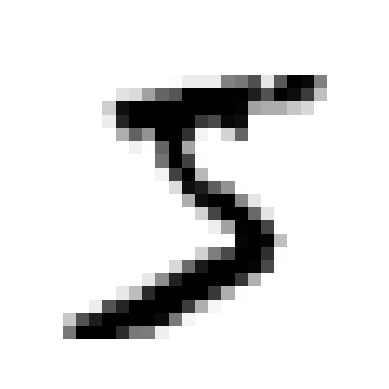

'5'

In [3]:
index=0
some_digit = X[index]
plot_digit(some_digit)
plt.show()
y[index] # Vemos que está correctamente etiquetado

Este dataset define tradicionalmente que las primeras 60000 muestras son para training y las últimas 10000 para test.

In [4]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Entrenamiento de un Clasificador Binario

Vamos a crear inicialmente un modelo que simplemente clasifique si un dígito es 5 o no.

In [5]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

Vamos a usar, por ejemplo, un clasificador `SGDClassifier`. Este clasificador implementa un descenso de gradiente estocástico (una aproximación al [descenso de gradiente](https://www.youtube.com/watch?v=A6FiCDoz8_4) que busca ser menos costoso computacionalmente) sobre algún algoritmo lineal de *machine learning* como la regresión lineal o las máquinas de soporte vectorial (SVM). Por defecto usa SVM.

In [6]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [ ]:
sgd_clf.predict([some_digit])

array([ True])

## *Accuracy* Usando *Cross-Validation*

Vamos a usar la función `cross_val_score` para calcular la *accuracy* (el porcentaje de aciertos) de nuestro modelo usando **cross-validation**.

> **Nota terminológica (para hispanohablantes):** El término inglés ***accuracy*** suele traducirse erróneamente como "***precisión***". En estadística y machine learning, el término correcto en español es **exactitud**. **Precisión** se refiere a una métrica completamente diferente: ***precision***.

[![](../img/diana.png)](https://es.wikipedia.org/wiki/Precisi%C3%B3n_y_exactitud)

In [9]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

Parece que nuestro modelo es muy bueno, ya que acierta más del 95% de las veces.

Sin embargo, veamos qué sucede si usamos un clasificador cuyo único algoritmo consiste en devolver siempre la etiqueta más frecuente. En este caso, como la mayoría de las etiquetas son `False` (es decir, la mayoría no eran `'5'`), este modelo siempre clasificará como `False`.

In [7]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # Siempre devuelve false

False


In [10]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

Encontramos que este modelo absurdamente simple tiene una tasa de acierto del 90%. Pero claro, eso es porque efectivamente, solo el 10% de las muestras eran '5' (tenemos 10 dígitos distribuidos uniformemente). Nuestro `DummyClassifier` acierta para todos los valores que no son 5, que al ser la mayoría nos da una alta accuracy (no hay falsos positivos), pero no acierta ninguno de los que sí lo son.

Con este ejemplo, queda clara la necesidad de mejores métricas de rendimiento en problemas de clasificación que simplemente la *accuracy*. <!--TODO: ¿especialmente para datasets no balanceados? ¿asimétricos? ¿no uniformes?-->

## Matriz de Confusión

Una matriz de confusión es una forma de visualizar el rendimiento de un algoritmo de clasificación. Cada fila representa una clase real, mientras que cada columna representa una clase predicha. Los elementos de la diagonal principal representan predicciones correctas, mientras que los elementos fuera de la diagonal principal representan predicciones incorrectas.

Hemos reservado el conjunto de test para la evaluación final del modelo, pero la función `cross_val_predict` nos permite obtener las predicciones de cada instancia en el conjunto de training mediante cross-validation.

In [11]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3) # predictions
y_train_pred

array([ True, False, False, ...,  True, False, False], shape=(60000,))

y con ellas podemos construir una matriz de confusión.

In [12]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_train_5, y_train_pred)
conf_matrix

array([[53892,   687],
       [ 1891,  3530]])

donde la primera fila indica los negativos (no 5) y la segunda los positivos (5). La primera columna indica los negativos predichos y la segunda los positivos predichos. Así, la matriz cuenta 53892 verdaderos negativos, 687 falsos positivos, 1891 falsos negativos y 3530 verdaderos positivos.

![precision_recall](../img/conf_matrix_5.png)

Para aclarar, imaginemos cómo sería la matriz de confusión para un clasificador perfecto.

In [13]:
confusion_matrix(y_train_5, y_train_5)

array([[54579,     0],
       [    0,  5421]])

Observamos cómo desaparecen los falsos positivos y los falsos negativos, y solo quedan los verdaderos positivos (5421) y los verdaderos negativos (54579). El clasificador sería perfecto.

## Precision y *Recall*

La **precision** de un clasificador es el número de predicciones correctas dividido por el total de predicciones positivas, es decir: el porcentaje de predicciones positivas que son correctas, o lo que es lo mismo, el porcentaje de predicciones positivas acertadas.

$$ \text{Precision} = \frac{TP}{TP + FP} $$

El **recall** (también llamado **sensibilidad** o **tasa de verdaderos positivos**) es el número de predicciones correctas dividido por el total de instancias que deberían haberse predicho como positivas, es decir: el porcentaje de positivos (valores que son '5') predichos correctamente.

$$ \text{Recall} = \frac{TP}{TP + FN} $$

[![](../img/classfication_metrics.jpg)](https://medium.com/swlh/how-to-remember-all-these-classification-concepts-forever-761c065be33)

In [14]:
from sklearn.metrics import precision_score, recall_score

print("Precisión:", precision_score(y_train_5, y_train_pred)) # == 3530 / (687 + 3530)
print("Precisión:", conf_matrix[1, 1] / (conf_matrix[0, 1] + conf_matrix[1, 1])) # manualmente desde la matriz de confusión
print("Recall:", recall_score(y_train_5, y_train_pred)) # == 3530 / (1891 + 3530)

Precisión: 0.8370879772350012
Precisión: 0.8370879772350012
Recall: 0.6511713705958311


Vemos que nuestro clasificador, a pesar de tener una *accuracy* alta, solo acierta el 83.7% de las veces cuando dice que un dígito es un '5'. Y solo detecta el 65.1% de los '5'. Esta métrica solo será alta cuando tanto la precision como el *recall* sean altos.

Existe otra métrica muy popular que es la media armónica entre precision y *recall*, el *F1 Score*:

$$ F1 = \frac{2}{\frac{1}{\text{Precision}} + \frac{1}{\text{Recall}}} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{TP}{TP + \frac{FN + FP}{2}} $$

In [15]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

En algunos contextos se prefiere la precision, en otros el recall. Por ejemplo, si entrenamos un clasificador para detectar videos seguros para niños, probablemente preferimos un clasificador que rechace muchos videos buenos (**bajo recall**) pero que mantenga solo los seguros (**alta precision**). Por otro lado, si entrenamos un clasificador para detectar ladrones en imágenes de vigilancia, probablemente está bien que nuestro clasificador solo tenga un 30% de precision (muchas **falsas alarmas**) siempre que tenga un 99% de **recall**, es decir: que sea muy **sensible**.

En general, a mayor precision, menor recall, y viceversa. Esto se denomina el ***trade-off* entre precision y recall**.

Para mostrar todas las métricas de un clasificador, podemos usar la función `classification_report`.

In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_train_5, y_train_pred))

              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



## Clasificación Multiclase

Hay clasificadores que pueden manejar múltiples clases directamente, como la regresión logística o los decision trees. Otros clasificadores son estrictamente binarios, como las máquinas de soporte vectorial. Sin embargo, existen estrategias para extenderlos a clasificadores multiclase.

Hay principalmente dos estrategias para extender un clasificador binario a un clasificador multiclase:

- ***One-versus-the-rest* (OvR)** o *One-versus-all* (OvA): Entrenar un clasificador binario para cada clase. Cuando queremos clasificar una instancia, obtenemos la puntuación de decisión de cada clasificador y seleccionamos la clase cuya puntuación es la más alta. En este caso, entrenaremos 10 clasificadores binarios, uno para cada dígito, análogo al que entrenamos para clasificar si un dígito es 5 o no.

- ***One-versus-one* (OvO)**: Entrenar un clasificador binario para cada par de clases. Si hay N clases, necesitamos entrenar N * (N - 1) / 2 clasificadores: 1 para distinguir el 0 y el 1, otro para distinguir el 0 y el 2, otro para distinguir el 1 y el 2, etc. La clase que gana la mayoría de los duelos es la seleccionada. Este método necesita entrenar muchos más clasificadores que el anterior, pero cada uno solo necesita entrenarse en una parte del conjunto de training.

Scikit-learn detecta automáticamente si estamos intentando usar un **clasificador binario** para una tarea de **clasificación multiclase** y aplica una u otra estrategia dependiendo del algoritmo (generalmente OvR, excepto para algoritmos que escalan mal con el aumento de muestras, como SVM)

In [ ]:
from sklearn.svm import SVC # Support Vector Classifier, usando OvO

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

In [ ]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

También es posible forzar el uso de una técnica u otra con los clasificadores de Scikit-learn, usando las clases `OneVsOneClassifier` o `OneVsRestClassifier`.

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [ ]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

Hemos usado SVM con OvO por defecto y OvR forzado. También podemos usar de nuevo SGDClassifier, que también aplica OvR por defecto.

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train[:2000], y_train[:2000])
sgd_clf.predict([some_digit])

array(['5'], dtype='<U1')

En este caso se equivocó. Comparemos el rendimiento general de las 3 técnicas.

In [ ]:
nsamples = 10000 # try varying the number of samples

In [ ]:
print("SVC por defecto (SVM-OvO):",
      cross_val_score(svm_clf, X_train[:nsamples], y_train[:nsamples], cv=3, scoring="accuracy").mean())

In [ ]:
print("SVC con OvR:",
    cross_val_score(ovr_clf, X_train[:nsamples], y_train[:nsamples], cv=3, scoring="accuracy").mean())

In [ ]:
print("SVC por defecto optimizado con SGD:",
    cross_val_score(sgd_clf, X_train[:nsamples], y_train[:nsamples], cv=3, scoring="accuracy").mean())

Vemos que OvR es mucho más costoso computacionalmente a medida que aumenta el número de muestras. Por eso SVC aplica OvO por defecto. Por su parte, SGDClassifier es más rápido, pero menos eficiente.

## Fuentes

- [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 3rd Edition. Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967/) - Capítulo 3: Classification ([notebook](https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb))
- SVM Multiclase:
    - https://www.analyticsvidhya.com/blog/2021/05/multiclass-classification-using-svm/
    - https://www.baeldung.com/cs/svm-multiclass-classification